## 1. Parameters and File Paths

Update file_folder to point to your Suite2p output. Example data is in Suite2p_output_example/.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

save_svg = False

# --- Example data (runs as-is) ---
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
exp_name = 'example'
stimulation_on_time =  {23.355, 53.095, 83.214, 112.867}
stimulation_duration = 1805  # ms
file_folder = os.path.join(BASE_DIR, 'Suite2p_output_example', 'suite2p', 'plane0') + os.sep
plt_result_folder = os.path.join(BASE_DIR, 'suite2p_example_output') + os.sep
os.makedirs(plt_result_folder, exist_ok=True)

F = np.load(file_folder + 'F.npy', allow_pickle=True)
Fneu = np.load(file_folder + 'Fneu.npy', allow_pickle=True)
spks = np.load(file_folder + 'spks.npy', allow_pickle=True)
stat = np.load(file_folder + 'stat.npy', allow_pickle=True)
ops =  np.load(file_folder + 'ops.npy', allow_pickle=True)
ops = ops.item()
iscell = np.load(file_folder + 'iscell.npy', allow_pickle=True)

In [2]:
# Configure matplotlib for proper inline plotting
%matplotlib inline
import matplotlib
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# Set a compatible backend for Jupyter
matplotlib.rcParams['figure.max_open_warning'] = 0
matplotlib.rcParams['axes.unicode_minus'] = False

print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Matplotlib backend: {matplotlib.get_backend()}")
print("Matplotlib configured for Jupyter notebook")

Matplotlib version: 3.8.4
Matplotlib backend: module://matplotlib_inline.backend_inline
Matplotlib configured for Jupyter notebook


## 2. Load Suite2p Output

The `.npy` files (F, Fneu, spks, stat, ops, iscell) are loaded from `file_folder` defined in Section 2.

In [3]:
#print the information about the recording
print(f"Number of ROIs: {F.shape[0]}")
print(f"Number of frames: {F.shape[1]}")
print(f"Frame rate: {ops['fs']} Hz")
print(f"Number of cells identified: {np.sum(iscell[:, 0])}")

Number of ROIs: 243
Number of frames: 2000
Frame rate: 30.0 Hz
Number of cells identified: 52.0


## 3. Identify Cell ROIs

Filter Suite2p ROIs to cells classified as neurons (`iscell == 1`) and build index maps.

In [4]:
#select the ROI of interest
selected_roi = [56, 6, 104, 23, 18, 114]#
#record index of ROIs classified as cells
roi_ind = np.where(iscell[:, 0] == 1)[0]
print(f"Found {len(roi_ind)} cells at indices: {roi_ind}")

#create a dictionary to store roi index and corresponding cell number
roi_cell_dict = {roi_ind[i]: i for i in range(len(roi_ind))}

F_roi = F[roi_ind, :]
spks_roi = spks[roi_ind, :]
Fneu_roi = Fneu[roi_ind, :]

Found 52 cells at indices: [  1   4   6   7   8   9  10  12  13  14  15  16  18  21  23  26  27  29
  31  32  35  36  37  39  40  42  44  49  50  56  59  63  65  66  67  70
  71  73  74  75  79  85  95  96 101 104 114 116 133 152 156 212]


## 4. Stimulation Timing

In [5]:
# Simplified stimulation timing — uses stimulation_on_time defined in parameters above.
# This cell works with the example data as-is.
#simplified stimulation
stimulus_bin = np.zeros((len(Fneu_roi[0]),))

fs=15.2
stimulation_on = [int(time * fs) for time in stimulation_on_time] #convert to frame number based on frame rate

duration = int(stimulation_duration / 1000 * fs)
for onset in stimulation_on:
    stimulus_bin[onset:onset + duration] = 1

In [6]:
# Define downstream variables for the simplified stimulation path
# (These are set by the Prairie View cells above when using a CSV)
if "stimulus" not in locals():
    stimulus_onsets = np.where(np.diff(stimulus_bin) == 1)[0]
    stimulation_endpoints = stimulus_onsets + duration
    reps = len(stimulus_onsets)
    spike_counts_before = np.zeros((len(roi_ind), reps))
    spike_counts_after = np.zeros((len(roi_ind), reps))
    # No shutter artifact for simplified stimulation
    F_roi_corrected = F_roi.copy()
    F_roi_neu_corrected = Fneu_roi.copy()
print(f"stimulus_onsets: {stimulus_onsets}")
print(f"reps: {reps}, duration: {duration} frames")


stimulus_onsets: [ 353  806 1263 1714]
reps: 4, duration: 27 frames


## 5. Plot Fluorescence Traces

Plot raw fluorescence and deconvolved spikes for selected ROIs.

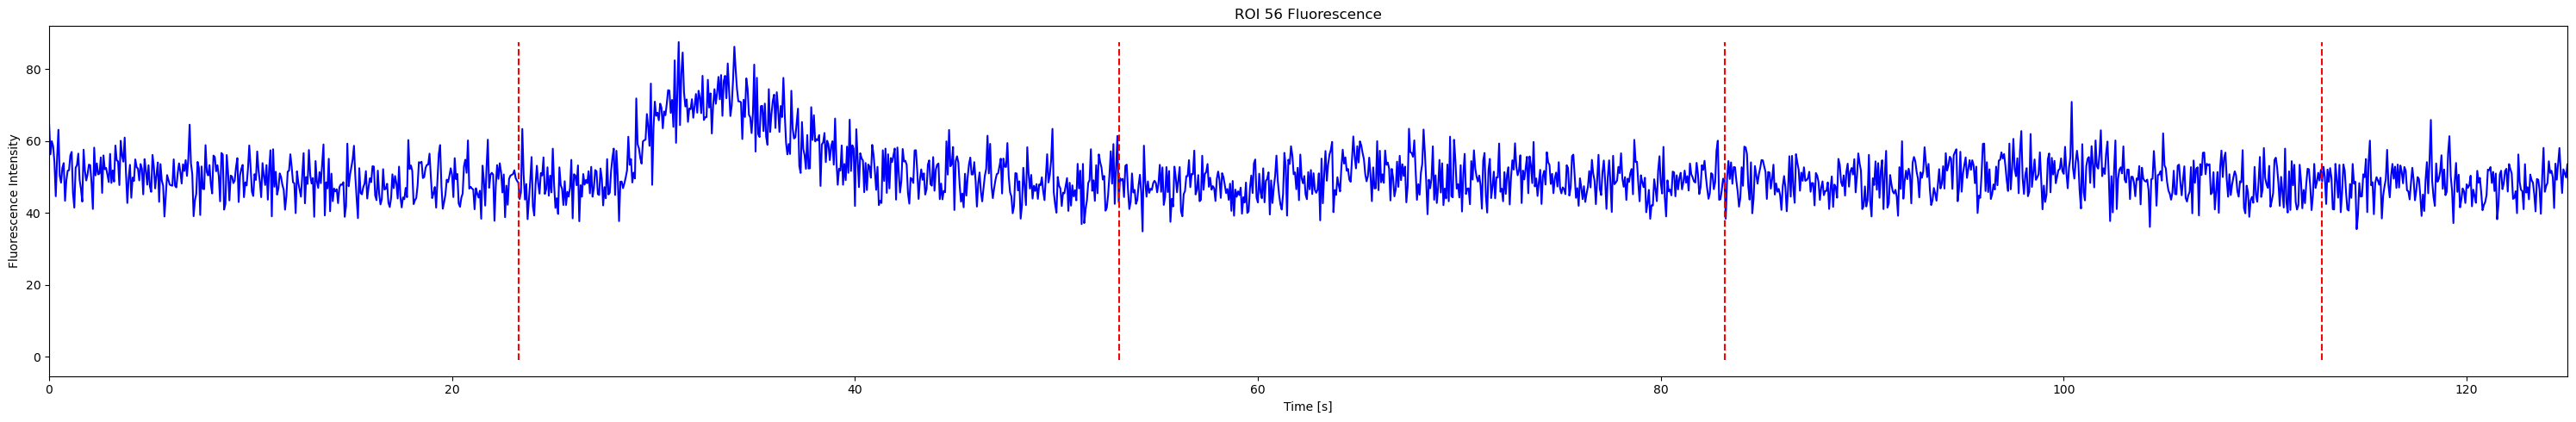

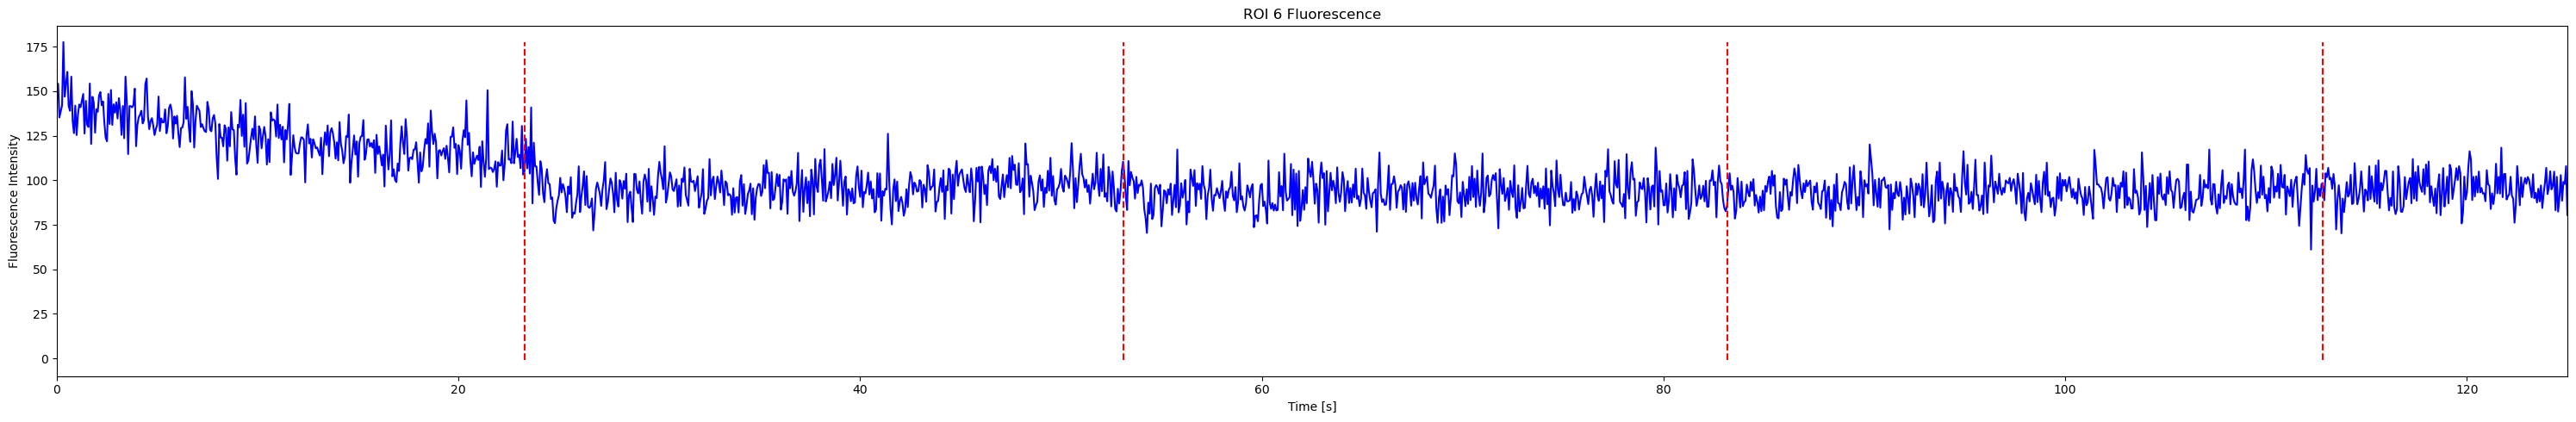

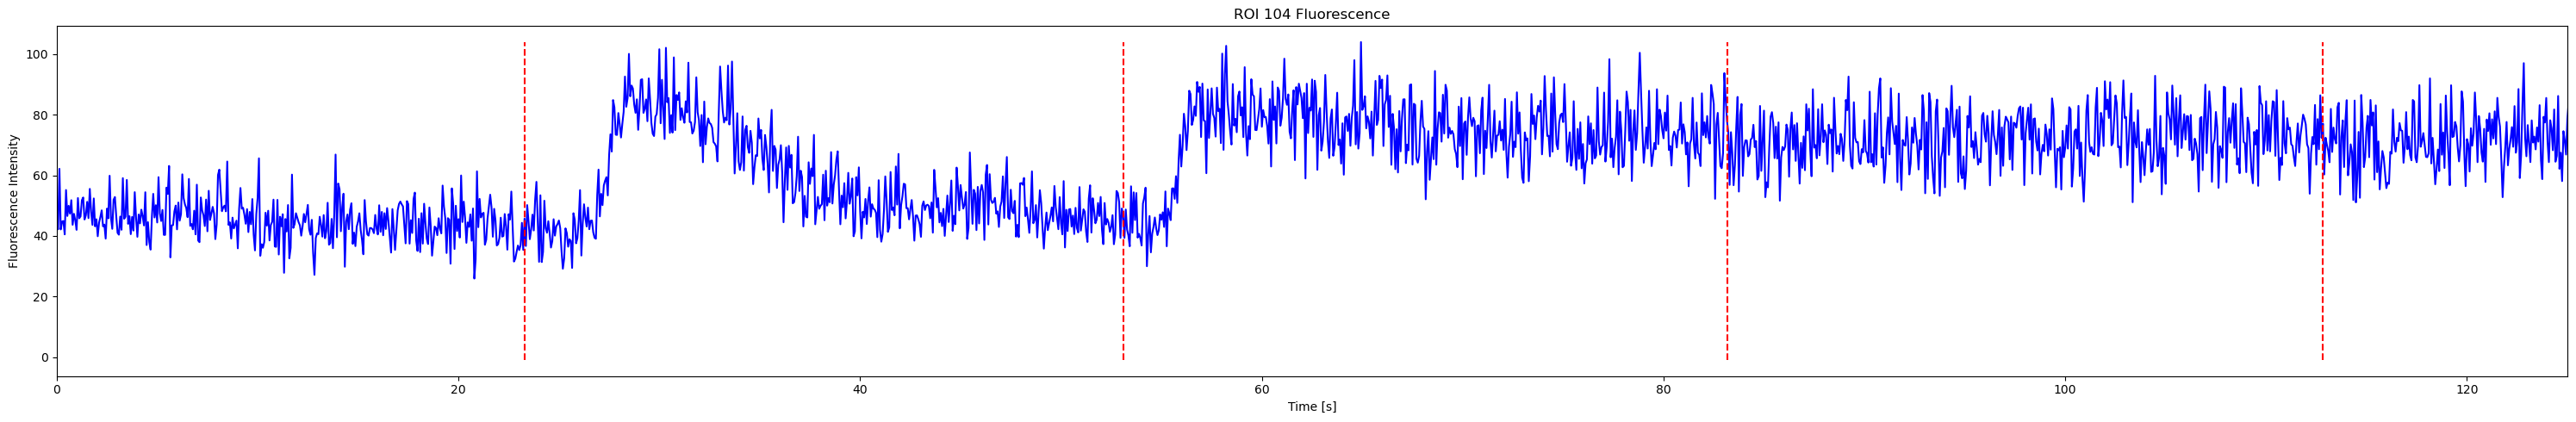

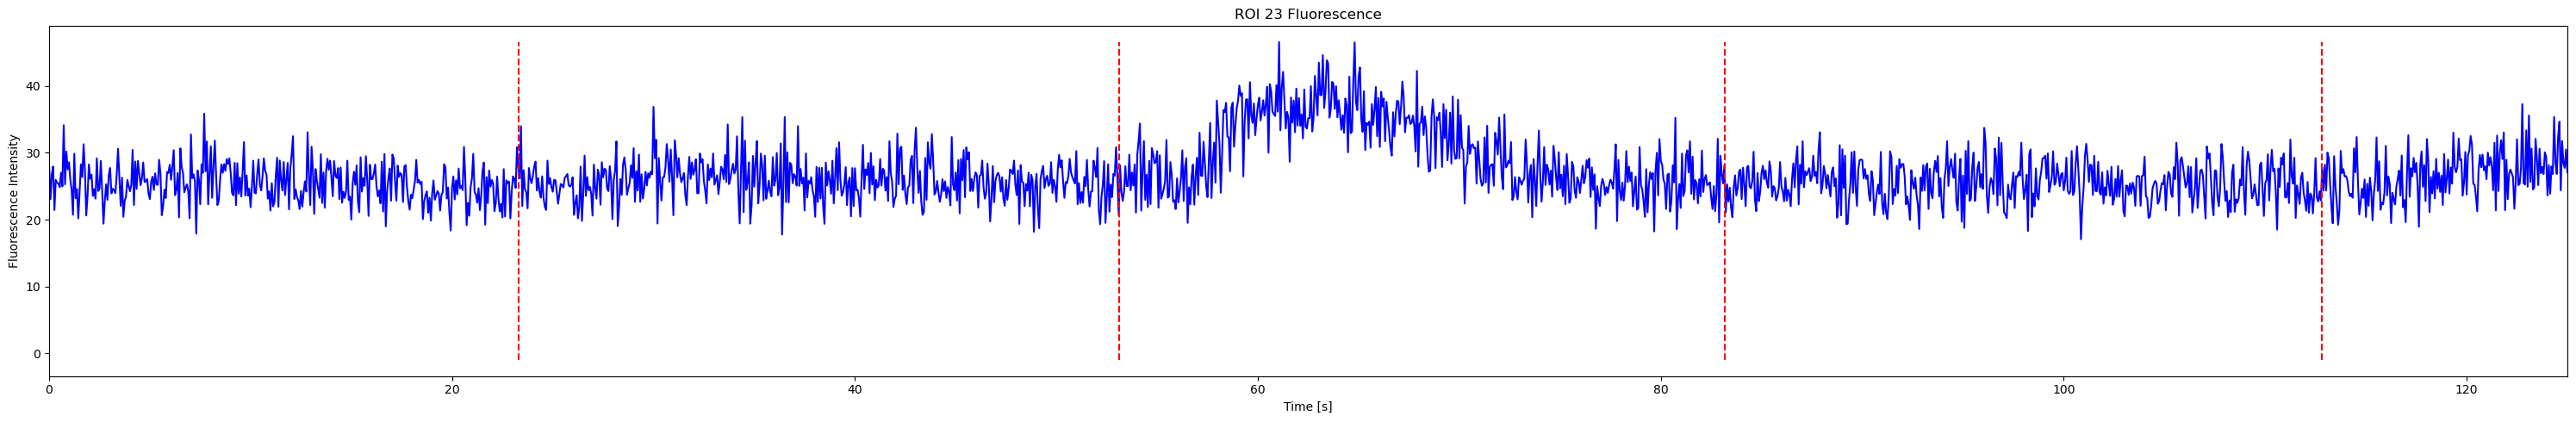

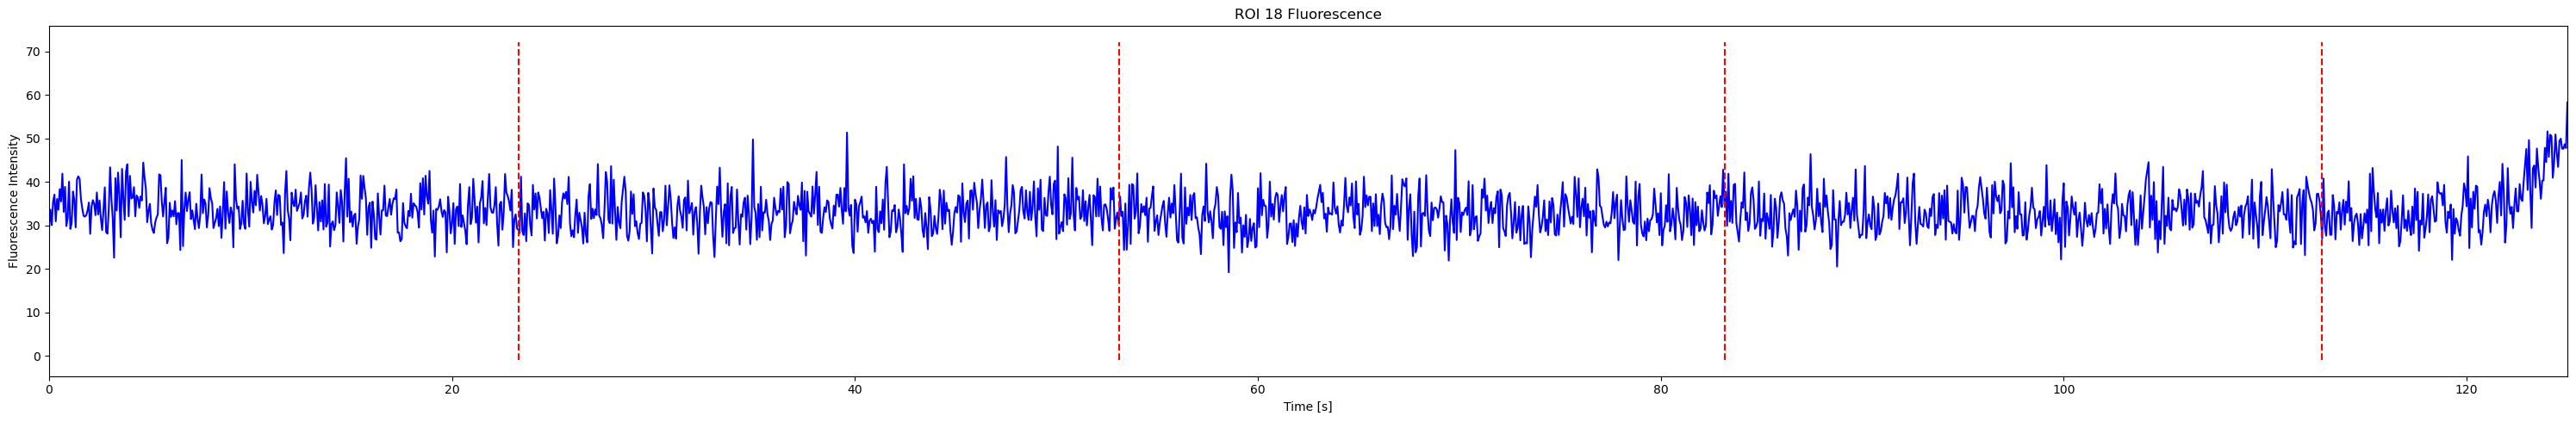

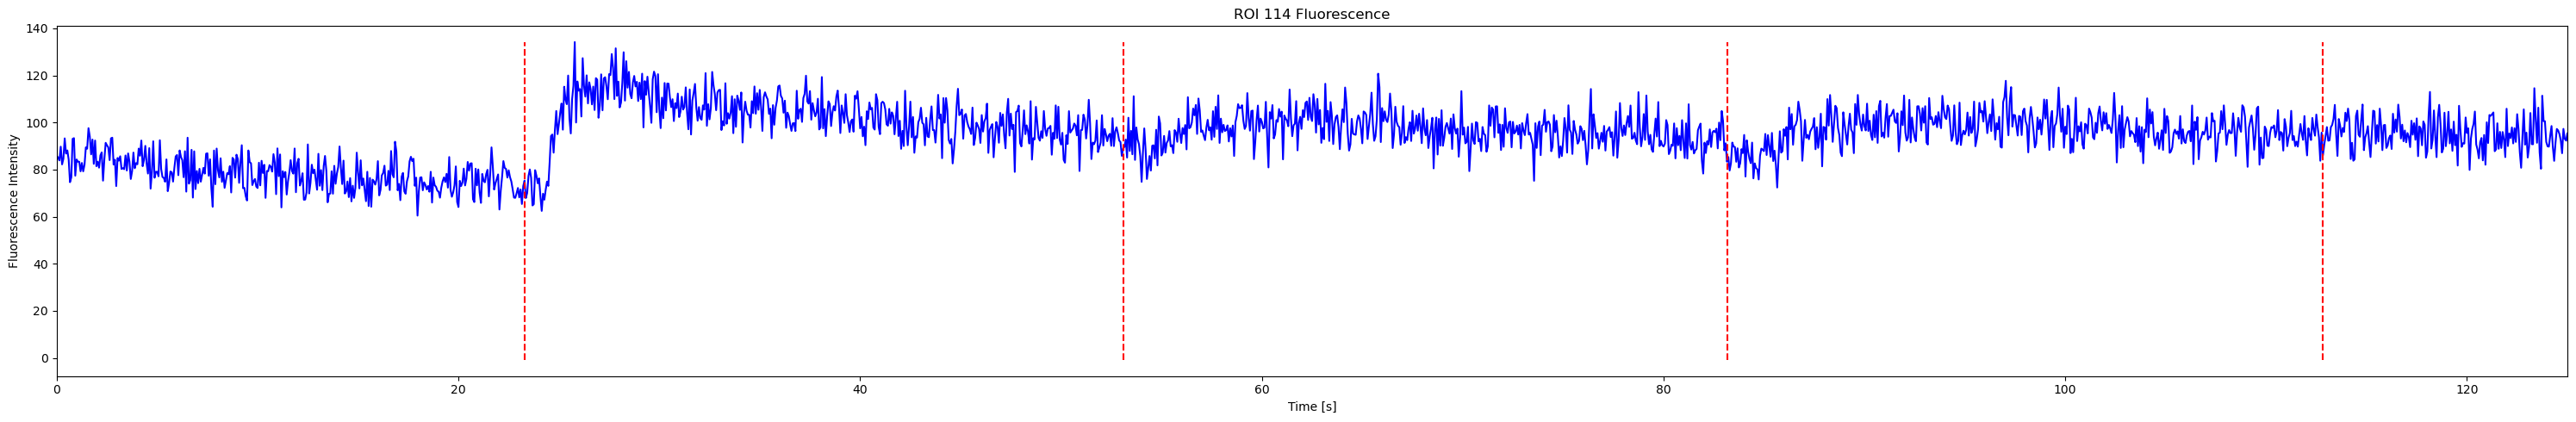

In [7]:
#plot fluorescence and spiking activity for the all ROIs
time = np.arange(F_roi.shape[1]) / fs  # Time in seconds
for i in range(len(selected_roi)):
    key = selected_roi[i]
    roi_to_plot = roi_cell_dict.get(key)
    fig = plt.figure(figsize=(30, 5))
    fig = plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1)
    # Plot fluorescence
    plt.plot(time, F_roi[roi_to_plot, :], label='Fluorescence (F)', color='blue')
    plt.title(f'ROI {roi_ind[roi_to_plot]} Fluorescence')
    plt.xlim(0, 125)
    plt.xlabel('Time [s]')
    plt.ylabel('Fluorescence Intensity')
    plt.vlines(np.array(list(stimulation_on))/fs, -1, max(F_roi[roi_to_plot, :]), colors='red', linestyles='dashed', label='Stimulus Onset')
    plt.tight_layout()
    plt.savefig(plt_result_folder + f'ROI_exp{exp_name}_{roi_ind[roi_to_plot]}_fluorescence.png', dpi=300)
    if save_svg:
        plt.savefig(plt_result_folder + f'ROI_exp{exp_name}_{roi_ind[roi_to_plot]}_fluorescence.svg')
    plt.show()

## 6. dF/F Heatmaps

Compute ΔF/F for all ROIs and display as a time × ROI heatmap.

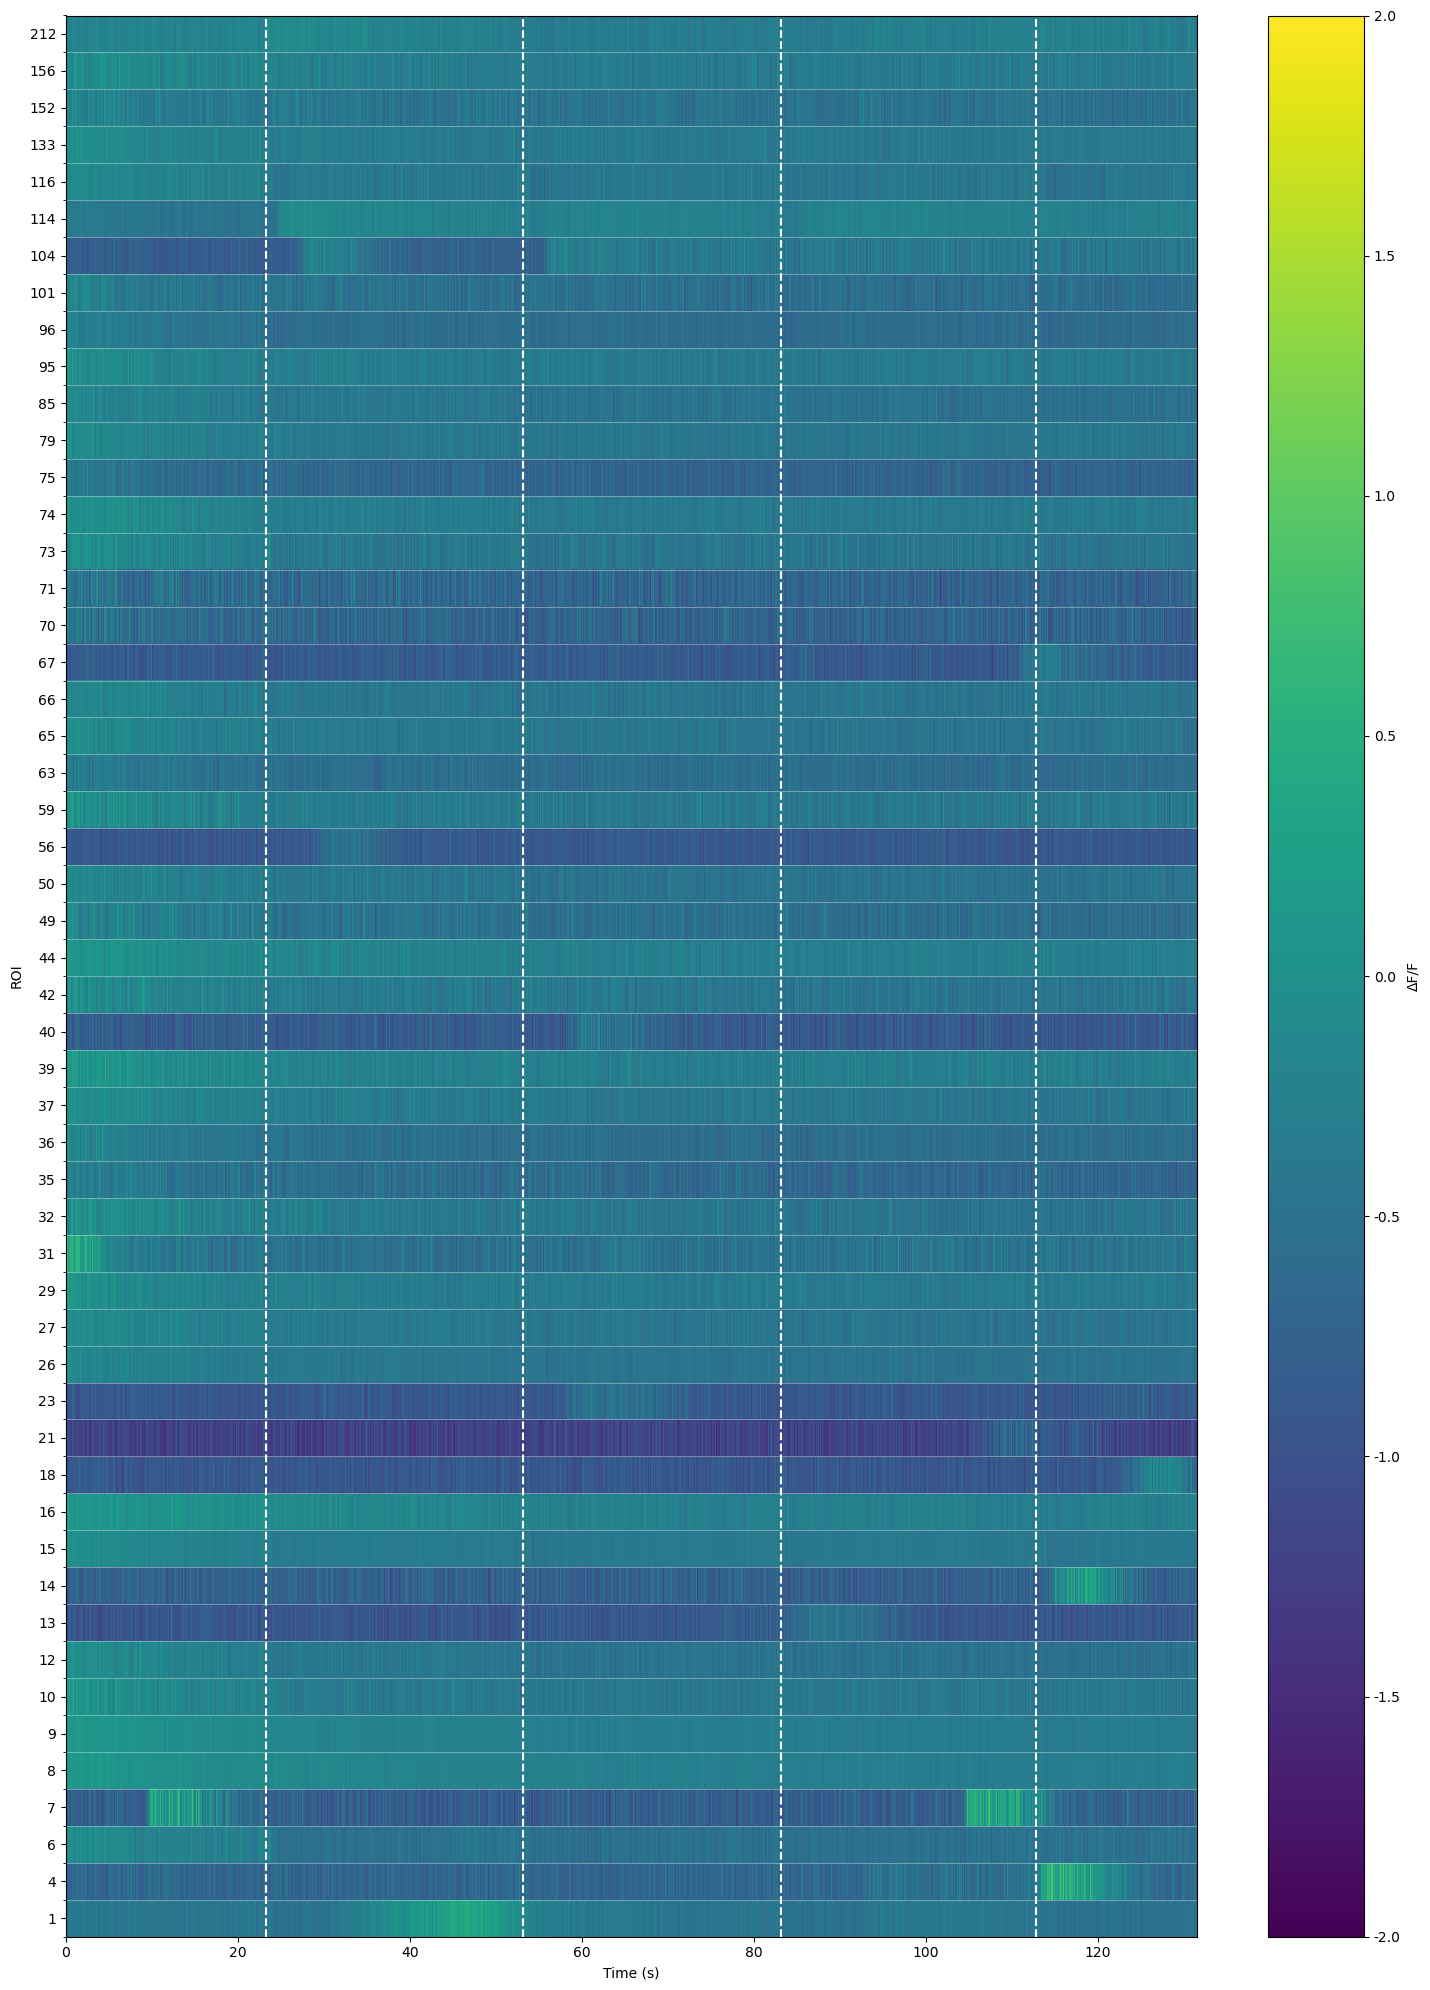

In [8]:
#plot dF/F traces for each ROI with stimulus times as heatmap one roi each row
#calculate F0 as the mean of 2s before the first stimulus
time = np.arange(F_roi.shape[1]) / fs
# F0 = running_mean_f0(F_roi, window_size=int(2*fs))
F0 = np.mean(F_roi, axis=1, keepdims=True)

dF_F = ((F_roi-Fneu_roi)-F0) / F0

n_rois, n_frames = dF_F.shape

# set colorbar range here
dff_vmin, dff_vmax = -2, 2

plt.figure(figsize=(15, 20))
plt.imshow(
    dF_F,
    aspect='auto',
    interpolation='nearest',
    extent=[time[0], time[-1], n_rois, 0],  # time in seconds
    vmin=dff_vmin,
    vmax=dff_vmax
)
#add stimulus times as vertical lines in seconds
for stim_time in list(stimulation_on):
    plt.axvline(x=stim_time/fs, color='white', linestyle='--')

plt.colorbar(label='ΔF/F')
plt.xlabel('Time (s)')
plt.ylabel('ROI')
row_centers = np.arange(n_rois) + 0.5
plt.yticks(ticks=row_centers, labels=roi_ind)

ax = plt.gca()
ax.set_yticks(np.arange(0, n_rois + 1), minor=True)
ax.grid(which='minor', axis='y', color='white', linestyle='-', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig(plt_result_folder + f'heatmap_all_ROI_exp{exp_name}.png', dpi=300)
if save_svg:
    plt.savefig(plt_result_folder + f'heatmap_all_ROI_exp{exp_name}.svg')
plt.show()


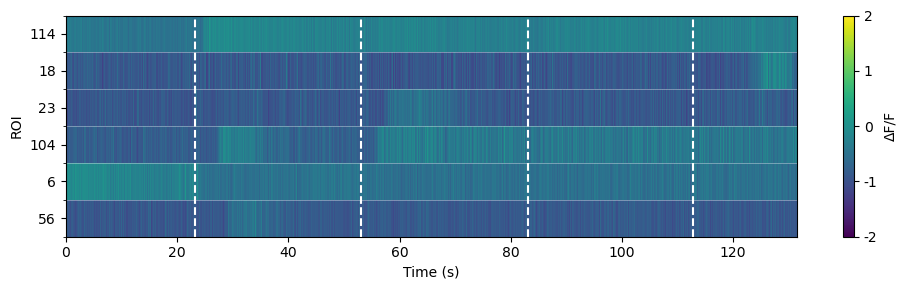

In [9]:
#heatmap with selected ROIs
seleced_roi_indices = [roi_cell_dict.get(key) for key in selected_roi]
dF_F_selected = dF_F[seleced_roi_indices, :]
plt.figure(figsize=(10, 3))
plt.imshow(
    dF_F_selected,
    aspect='auto',
    interpolation='nearest',
    extent=[time[0], time[-1], len(selected_roi), 0],  # time in seconds
    vmin=dff_vmin,
    vmax=dff_vmax
)
#add stimulus times as vertical lines in seconds
for stim_time in list(stimulation_on):
    plt.axvline(x=stim_time/fs, color='white', linestyle='--')

plt.colorbar(label='ΔF/F')
plt.xlabel('Time (s)')
plt.ylabel('ROI')
row_centers = np.arange(len(selected_roi)) + 0.5
plt.yticks(ticks=row_centers, labels=selected_roi)

ax = plt.gca()
ax.set_yticks(np.arange(0, len(selected_roi) + 1), minor=True)
ax.grid(which='minor', axis='y', color='white', linestyle='-', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig(plt_result_folder + f'selected_ROIs_exp{exp_name}_heatmap.png', dpi=300)
if save_svg:
    plt.savefig(plt_result_folder + f'selected_ROIs_exp{exp_name}_heatmap.svg')
plt.show()

## 7. ROI Localization

Visualize ROI positions on the mean image and compute pairwise distances.

/var/folders/yg/7q7k7r496k391dksyntr1q1w0000gn/T/ipykernel_33371/1676363315.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('plasma', roi_ind.shape[0])


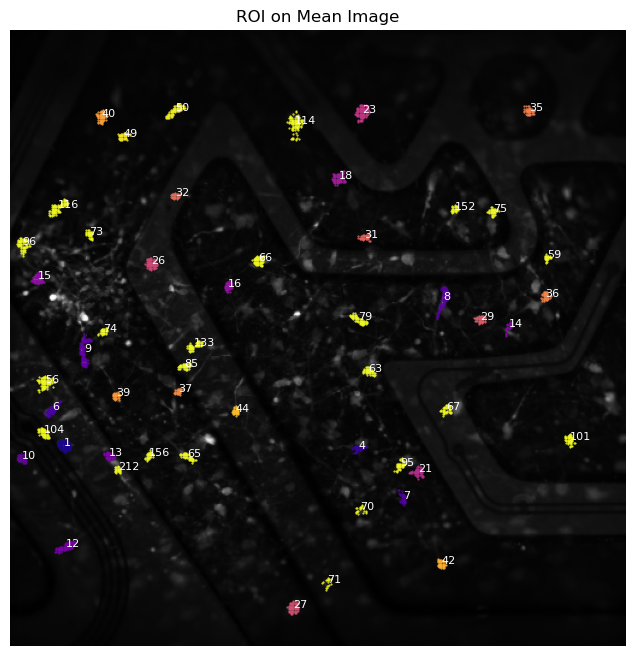

In [10]:
im = np.zeros((ops['Ly'], ops['Lx']))

import matplotlib.cm as cm
cmap = cm.get_cmap('plasma', roi_ind.shape[0])
# show contours of ROIs on mean image with text labels
mean_image = ops['meanImg']
plt.figure(figsize=(8, 8))
plt.imshow(mean_image, cmap='gray')
for n in roi_ind:
    ypix = stat[n]['ypix'][~stat[n]['overlap']]
    xpix = stat[n]['xpix'][~stat[n]['overlap']]
    plt.plot(xpix, ypix, '.', markersize=1, color=cmap(n))
    plt.text(np.mean(xpix), np.mean(ypix), str(n), color='white', fontsize=8)
plt.title('ROI on Mean Image')
plt.axis('off')
plt.savefig(plt_result_folder + f'exp{exp_name}_ROIs_on_mean_image.png', dpi=300)
if save_svg:
    plt.savefig(plt_result_folder + f'exp{exp_name}_ROIs_on_mean_image.svg')
plt.show()

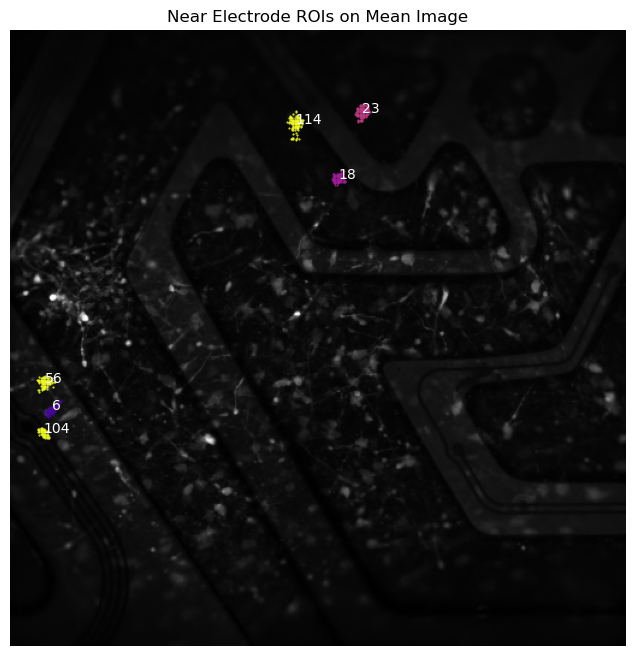

In [11]:
#plot only selected ROIs on mean image with text labels
plt.figure(figsize=(8, 8))
plt.imshow(mean_image, cmap='gray')
for n in selected_roi:
    ypix = stat[n]['ypix'][~stat[n]['overlap']]
    xpix = stat[n]['xpix'][~stat[n]['overlap']]
    plt.plot(xpix, ypix, '.', markersize=1, color=cmap(n))
    plt.text(np.mean(xpix), np.mean(ypix), str(n), color='white', fontsize=10)
plt.title('Near Electrode ROIs on Mean Image')
plt.axis('off')
plt.savefig(plt_result_folder + f'exp{exp_name}_selected_ROIs_on_mean_image.png', dpi=300)
if save_svg:
    plt.savefig(plt_result_folder + f'exp{exp_name}_selected_ROIs_on_mean_image.svg')
plt.show()

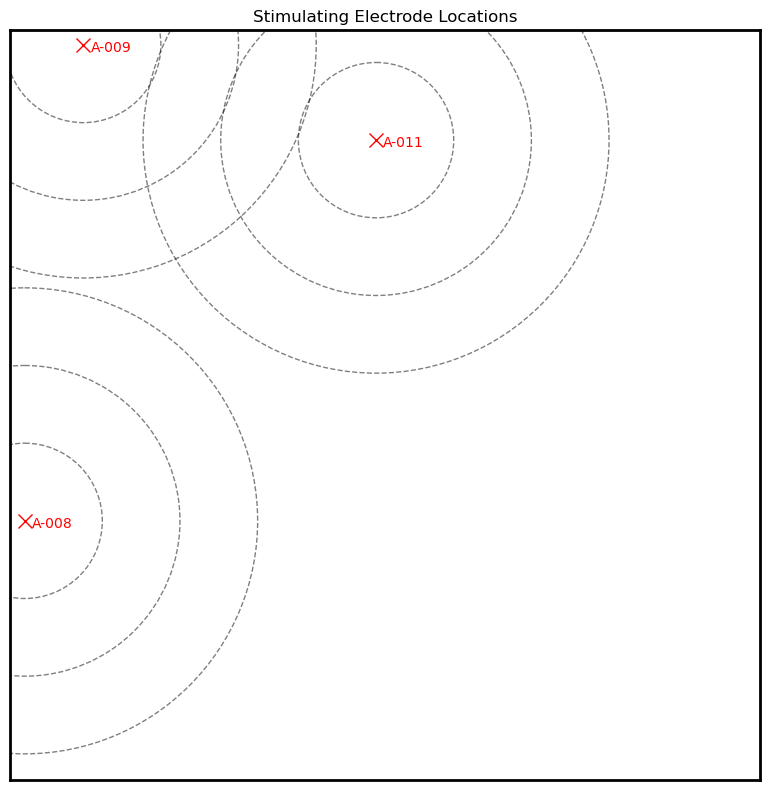

In [12]:
#define stimulation electrode locations approximate
# stimulation_locations = {'A-008': (10, 335), 'A-009': (50, 10), 'A-011':(250, 75), 'B-010': (500, 210), 'B-011':(370, 350)}
# stimulation_locations = {'B-010': (500, 210), 'B-011':(370, 350)}
stimulation_locations = {'A-008': (10, 335), 'A-009': (50, 10), 'A-011':(250, 75)}

# draw circles with radius of 50 microns around the stimulation locations
pixel_size = 1.8852
radius_microns = {100, 200, 300}
radius_pixels = {r: r / pixel_size for r in radius_microns}

# image dimensions
img_h, img_w = ops['Ly'], ops['Lx']

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_xlim(0, img_w)
ax.set_ylim(img_h, 0)
ax.set_facecolor('white')
ax.set_aspect('equal')

# draw black border around the square
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# plot electrode locations and distance rings (only if within image bounds)
for name, (x, y) in stimulation_locations.items():
    if 0 <= x < img_w and 0 <= y < img_h:
        ax.plot(x, y, 'x', markersize=10, color='red')
        for r in radius_pixels.values():
            ax.add_patch(plt.Circle((x, y), r, color='black', fill=False, linestyle='--', alpha=0.5))
        ax.text(x + 5, y + 5, name, color='red', fontsize=10)

ax.set_title('Stimulating Electrode Locations')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()


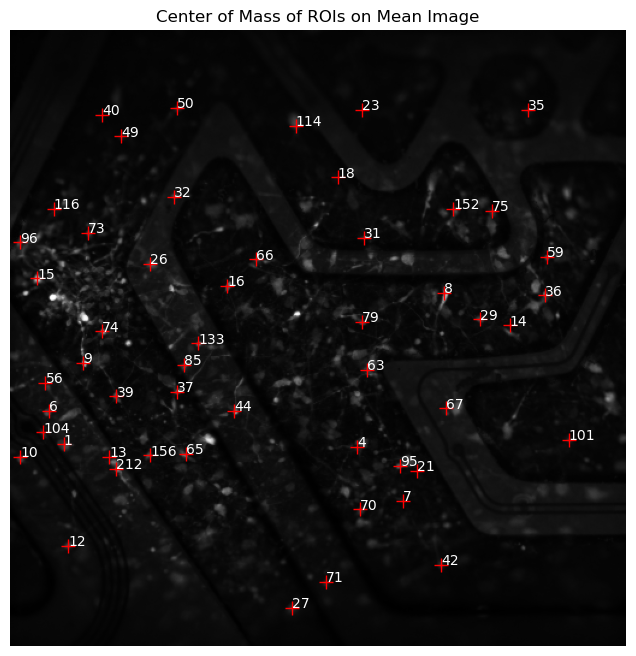

In [13]:
#show center of mass of ROIs on mean image with text labels
mean_image = ops['meanImg']
plt.figure(figsize=(8, 8))
plt.imshow(mean_image, cmap='gray')
for n in roi_ind:
    y_center = stat[n]['med'][0]
    x_center = stat[n]['med'][1]
    plt.plot(x_center, y_center, 'r+', markersize=10)
    plt.text(x_center, y_center, str(n), color='white', fontsize=10)
plt.title('Center of Mass of ROIs on Mean Image')
plt.axis('off')
plt.show()

In [14]:
#calucalte distance between each ROI to ROI of interest
ROI_interest = 3

y_interest = stat[ROI_interest]['med'][0]
x_interest = stat[ROI_interest]['med'][1]

distances = []
for n in roi_ind:
    y_n = stat[n]['med'][0]
    x_n = stat[n]['med'][1]
    distance = np.sqrt((y_n - y_interest) ** 2 + (x_n - x_interest) ** 2)
    distances.append((n, distance))

#convert distance to um
pixel_size = 1.8852
distances_um = [(n, dist * pixel_size) for n, dist in distances]

## 8. Spike Timing and Latency Analysis

Detect deconvolved spike events per ROI and compute response latencies relative to stimulation onsets.

In [15]:
# find spike timing for cell ROI using scipy signal
from scipy.signal import find_peaks
peakwidth = 300 #10 seconds

#sort spikes
std_threshold = 8
all_chan_peaks=[]
for idx in range(spks_roi.shape[0]):
    s = spks_roi[idx,:]
    sigma = np.std(s)
    p,_=find_peaks(s, height=std_threshold*sigma, distance=peakwidth)

    all_chan_peaks.append(np.vstack((np.ones(len(p))*idx,p)).T)
all_chan_peaks=np.concatenate(all_chan_peaks).astype(int) 

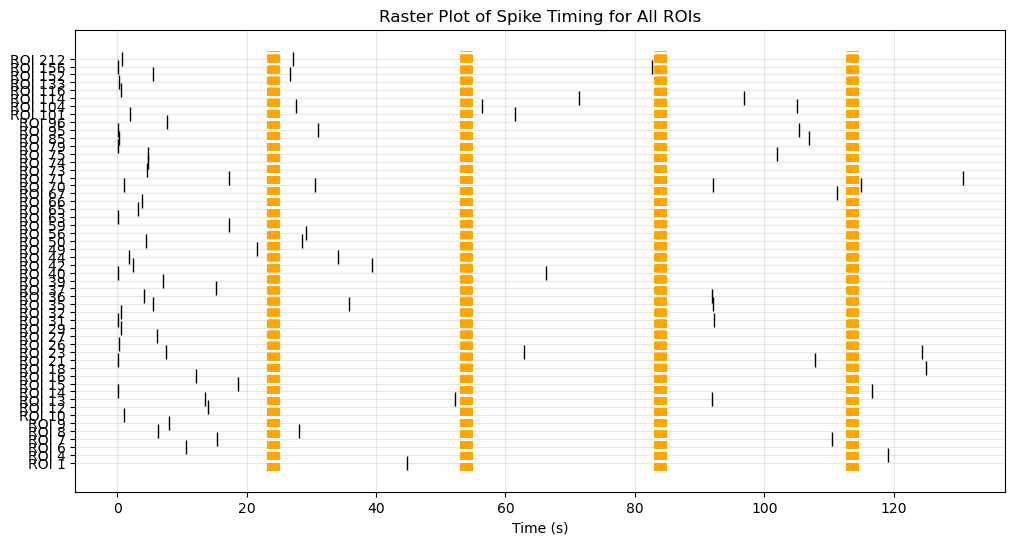

In [16]:
#raster plot of spike timing for all ROIs
plt.figure(figsize=(12, 6))
for peak in all_chan_peaks:
    plt.plot(peak[1]/fs, peak[0], '|', markersize=10, color='black')
# Overlay stimulus times
stimulus_times = np.where(stimulus_bin == 1)[0]
plt.vlines(stimulus_times/fs, -1, len(roi_ind), colors='orange', linestyles='dashed', label='Stimulus Onset')
plt.yticks(range(len(roi_ind)), [f'ROI {ind}' for ind in roi_ind])
plt.xlabel('Time (s)')
plt.title('Raster Plot of Spike Timing for All ROIs')
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
#calcualte average latency in spike timing for each ROI to stimulation time
average_latencies = []
responding_rois = []
duration = 450 #frames


#map roi_ind to natural index in all_chan_peaks
roi_ind_to_natural_index = {roi: i for i, roi in enumerate(roi_ind)}

for n in roi_ind:

    nature_ind = roi_ind_to_natural_index[n]
    
    #exclude the ROI of interest itself
    # if n == ROI_interest:
    #     continue

    latencies = []
    for stim_time in stimulation_on:
        n_peaks = all_chan_peaks[(all_chan_peaks[:,0] == nature_ind) & (all_chan_peaks[:,1] >= stim_time) & (all_chan_peaks[:,1] <= stim_time + duration)]

        #only caculate the latency of the first peaks after stimulus
        if len(n_peaks) == 0:
            continue
        latency = n_peaks[0,1] - stim_time
        latencies.append(latency)

    if latencies:
        avg_latency = np.mean(latencies) / fs  # convert to s
        average_latencies.append((n, avg_latency))
        responding_rois.append(n)
    

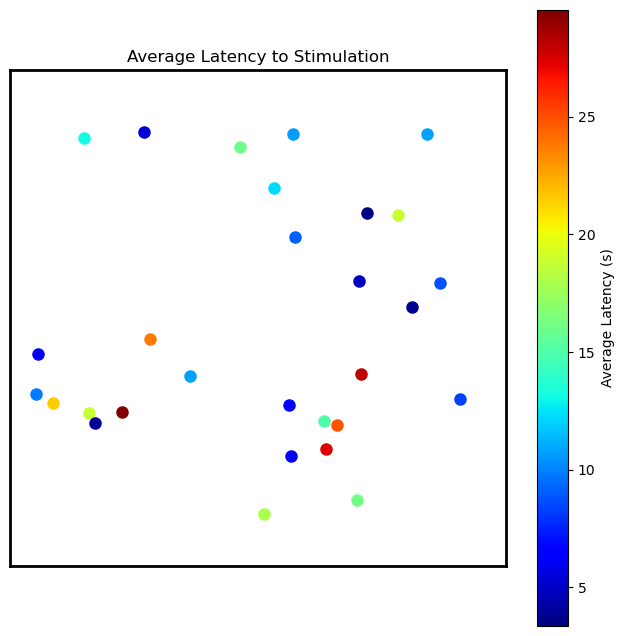

In [18]:
#color average latency on mean image
latency_dict = dict(average_latencies)

valid_latencies = [v for v in latency_dict.values() if not np.isnan(v)]
vmin, vmax = min(valid_latencies), max(valid_latencies)
norm = plt.Normalize(vmin=vmin, vmax=vmax)

mean_image = ops['meanImg']
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(0, img_w)
ax.set_ylim(img_h, 0)
ax.set_facecolor('white')
ax.set_aspect('equal')

# draw black border around the square
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

for n in responding_rois:
    y_center = stat[n]['med'][0]
    x_center = stat[n]['med'][1]
    latency = latency_dict[n]
    if np.isnan(latency):
        color = 'gray'
    else:
        color = plt.cm.jet(norm(latency))
    ax.plot(x_center, y_center, 'o', markersize=8, color=color)


ax.set_title('Average Latency to Stimulation')
ax.set_xticks([])
ax.set_yticks([])
plt.colorbar(plt.cm.ScalarMappable(cmap='jet', norm=norm), ax=ax, label='Average Latency (s)')
plt.savefig(plt_result_folder + f'average_latency.png', dpi=300)
if save_svg:
    plt.savefig(plt_result_folder + f'average_latency.svg')
plt.show()


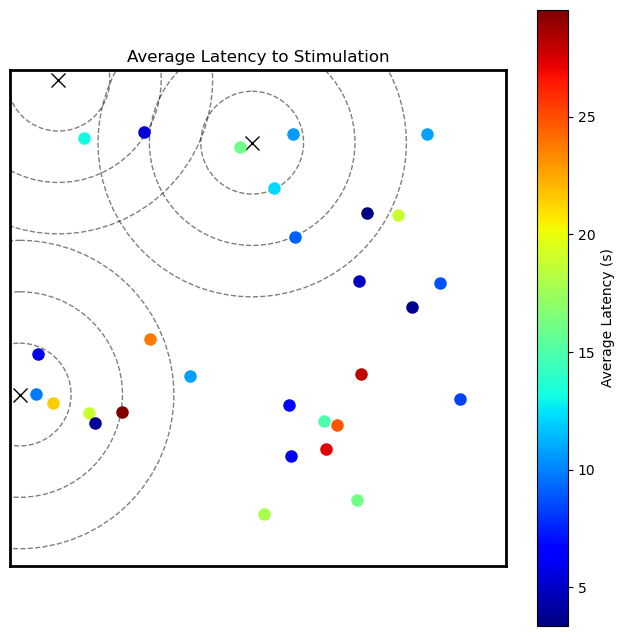

In [19]:
mean_image = ops['meanImg']
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(0, img_w)
ax.set_ylim(img_h, 0)
ax.set_facecolor('white')
ax.set_aspect('equal')

# draw black border around the square
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# plot electrode locations and distance rings (only if within image bounds)
for name, (x, y) in stimulation_locations.items():
    if 0 <= x < img_w and 0 <= y < img_h:
        ax.plot(x, y, 'x', markersize=10, color='black')
        for r in radius_pixels.values():
            ax.add_patch(plt.Circle((x, y), r, color='black', fill=False, linestyle='--', alpha=0.5))
        # ax.text(x + 5, y + 5, name, color='black', fontsize=10)

for n in responding_rois:
    y_center = stat[n]['med'][0]
    x_center = stat[n]['med'][1]
    latency = latency_dict[n]
    if np.isnan(latency):
        color = 'gray'
    else:
        color = plt.cm.jet(norm(latency))
    ax.plot(x_center, y_center, 'o', markersize=8, color=color)


ax.set_title('Average Latency to Stimulation')
ax.set_xticks([])
ax.set_yticks([])
plt.colorbar(plt.cm.ScalarMappable(cmap='jet', norm=norm), ax=ax, label='Average Latency (s)')
plt.savefig(plt_result_folder + f'average_latency_stimulation_electrodes.png', dpi=300)
if save_svg:
    plt.savefig(plt_result_folder + f'average_latency_stimulation_electrodes.svg')
plt.show()


In [20]:
# normalize fluorescence traces for each responding ROI by row using z-score
normalization_method = 'min-max'  # or 'min-max'
F_roi_responding = F[responding_rois, :]

if normalization_method == 'z-score':
    F_roi_normalized = F_roi_responding.copy()
    row_mean = np.mean(F_roi_responding, axis=1, keepdims=True)
    row_std = np.std(F_roi_responding, axis=1, keepdims=True)
    row_std = np.where(row_std == 0, 1, row_std)
    F_roi_normalized = (F_roi_responding - row_mean) / row_std
else:
    #normalize fluorescence traces by row using min-max normalization
    F_roi_normalized = (F_roi_responding - np.min(F_roi_responding, axis=1, keepdims=True)) / (np.max(F_roi_responding, axis=1, keepdims=True) - np.min(F_roi_responding, axis=1, keepdims=True))


## 9. Fluorescence Correlation

Compute pairwise correlation matrix of normalized fluorescence traces across ROIs.

In [21]:
# correlation matrix heatmap of normalized fluorescence traces + distance row
import seaborn as sns
import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform


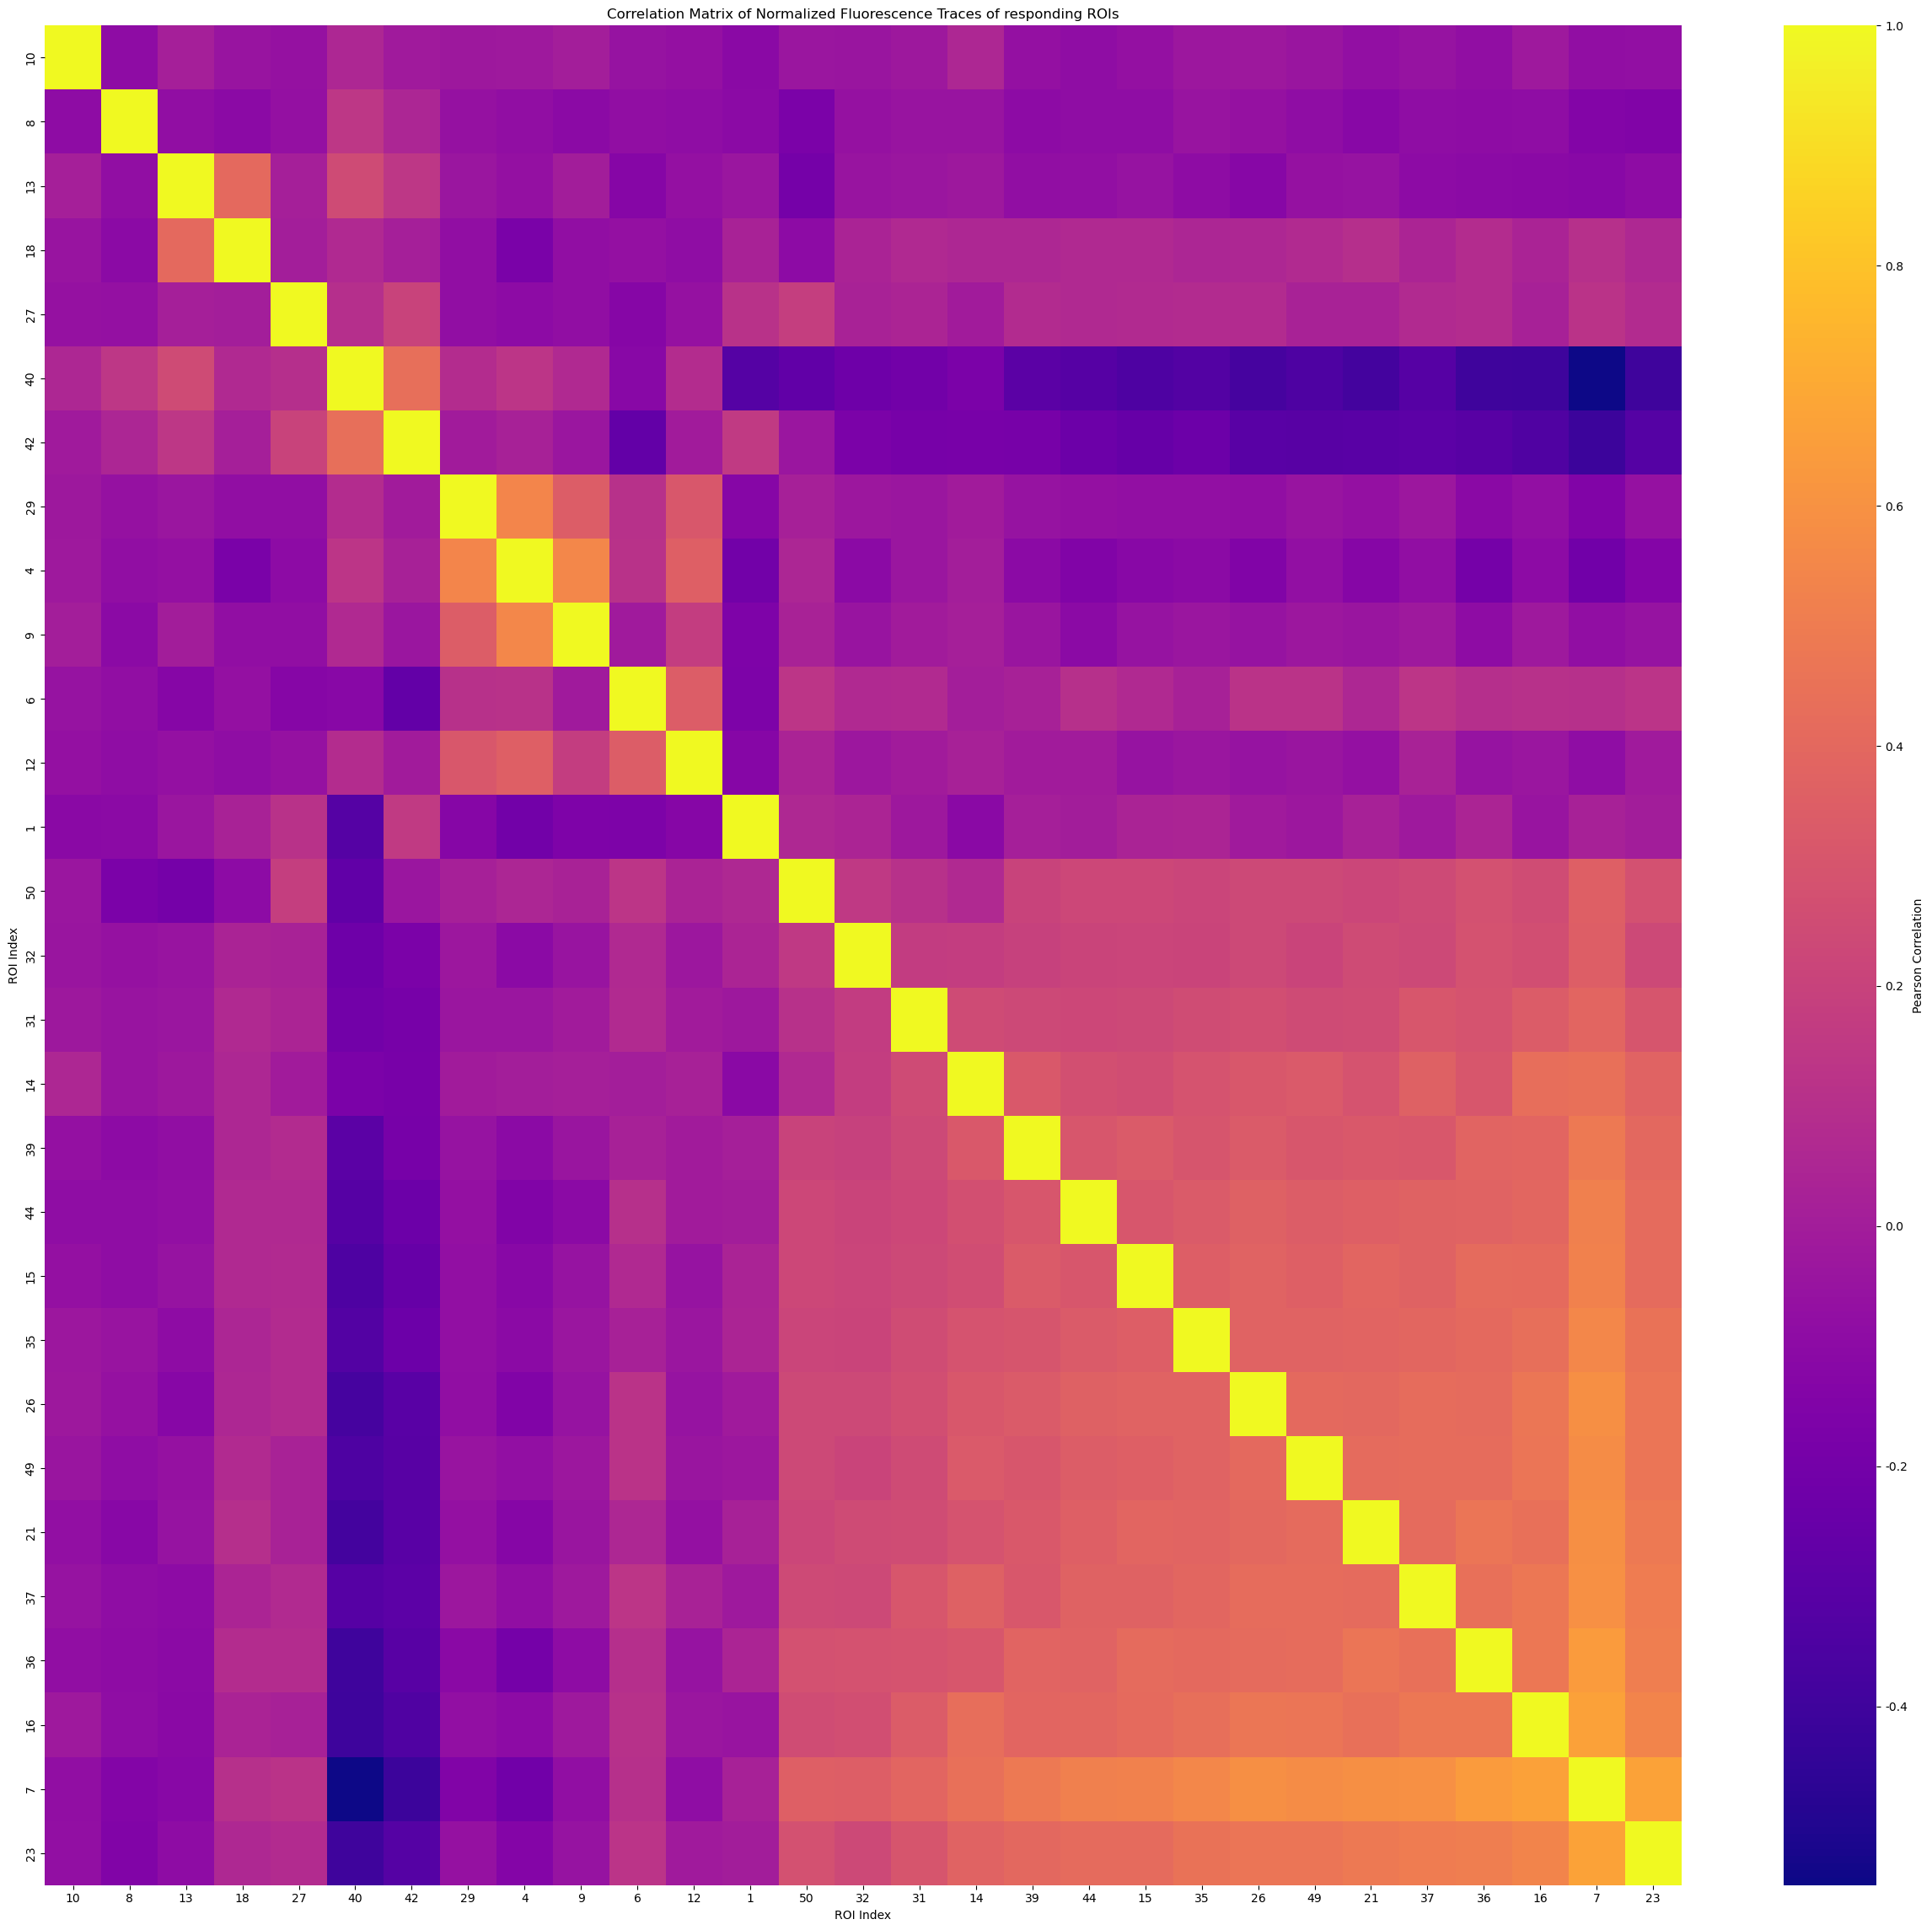

In [22]:
# only plot the correlation matrix sorted without distance map
corr_matrix = np.corrcoef(F_roi_normalized)
# label axes with ROI indices

# cluster rows/cols by correlation
corr_for_dist = np.clip(corr_matrix, -1, 1)
dist_matrix = 1 - corr_for_dist
linkage_matrix = linkage(squareform(dist_matrix, checks=False), method='average')
order = leaves_list(linkage_matrix)

corr_matrix_clustered = corr_matrix[np.ix_(order, order)]
roi_labels_clustered = [roi_ind[i] for i in order]

fig, ax = plt.subplots(figsize=(25, 23))
sns.heatmap(
    corr_matrix_clustered,
    cmap='plasma',
    xticklabels=roi_labels_clustered,
    yticklabels=roi_labels_clustered,
    ax=ax,
    cbar=True,
    cbar_kws={'label': 'Pearson Correlation'}
)
ax.set_title('Correlation Matrix of Normalized Fluorescence Traces of responding ROIs')
ax.set_ylabel('ROI Index')
ax.set_xlabel('ROI Index')
plt.tight_layout()
plt.savefig(plt_result_folder + 'correlation_matrix_responding_rois.png', dpi=300)
if save_svg:
    plt.savefig(plt_result_folder + 'correlation_matrix_responding_rois.svg')
plt.show()


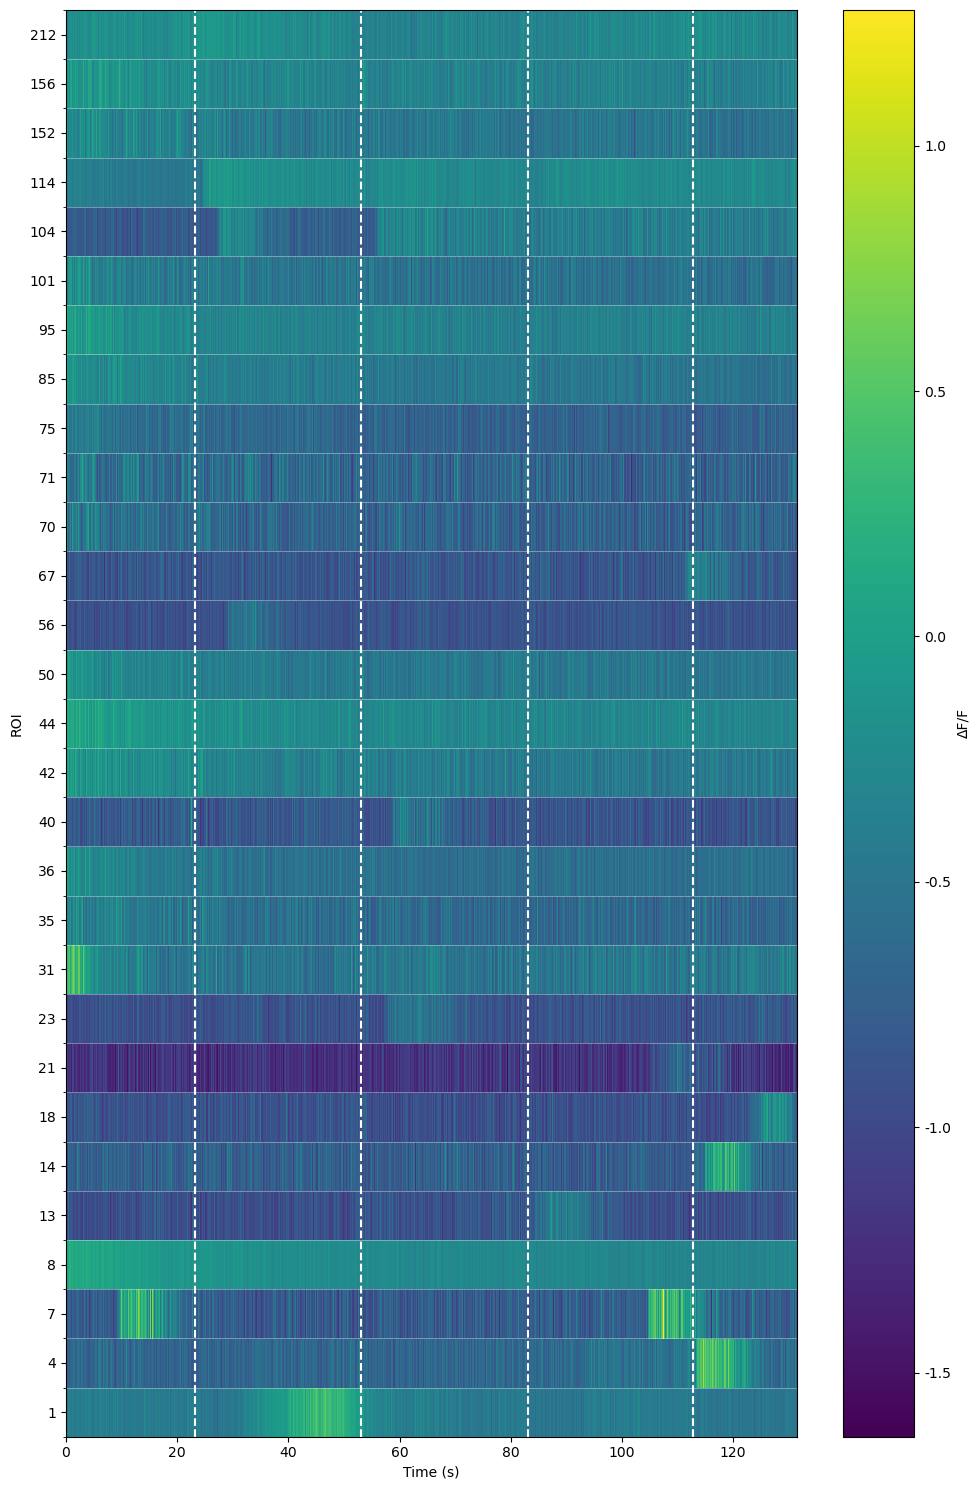

In [23]:
#heatmap wit responding ROIs
responding_roi_indices = [roi_cell_dict.get(key) for key in responding_rois]
dF_F_responding = dF_F[responding_roi_indices, :]
plt.figure(figsize=(10, 15))
plt.imshow(
    dF_F_responding,
    aspect='auto',
    interpolation='nearest',
    extent=[time[0], time[-1], len(responding_rois), 0]  # time in seconds
)
#add stimulus times as vertical lines in seconds
for stim_time in list(stimulation_on):
    plt.axvline(x=stim_time/fs, color='white', linestyle='--')

plt.colorbar(label='ΔF/F')
plt.xlabel('Time (s)')
plt.ylabel('ROI')
row_centers = np.arange(len(responding_rois)) + 0.5
plt.yticks(ticks=row_centers, labels=responding_rois)

ax = plt.gca()
ax.set_yticks(np.arange(0, len(responding_rois) + 1), minor=True)
ax.grid(which='minor', axis='y', color='white', linestyle='-', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig(plt_result_folder + f'responding_ROIs_exp{exp_name}_heatmap.png', dpi=300)
if save_svg:
    plt.savefig(plt_result_folder + f'responding_ROIs_exp{exp_name}_heatmap.svg')
plt.show()

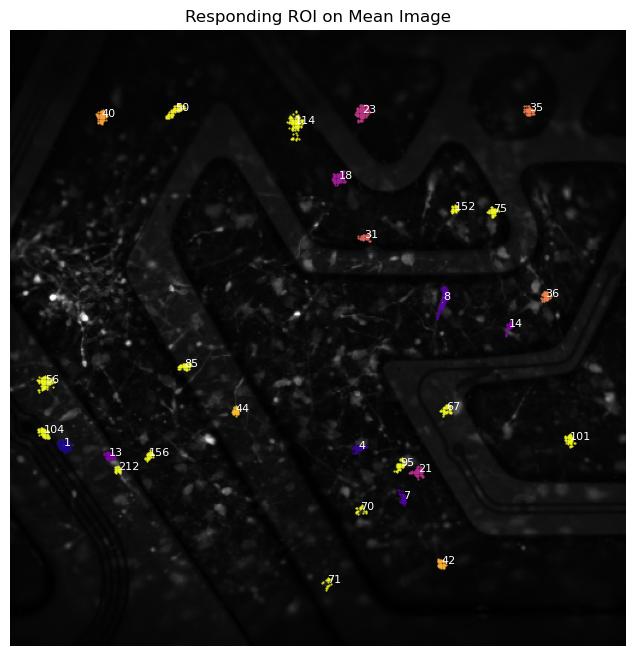

In [24]:
plt.figure(figsize=(8, 8))
plt.imshow(mean_image, cmap='gray')
for n in responding_rois:
    ypix = stat[n]['ypix'][~stat[n]['overlap']]
    xpix = stat[n]['xpix'][~stat[n]['overlap']]
    plt.plot(xpix, ypix, '.', markersize=1, color=cmap(n))
    plt.text(np.mean(xpix), np.mean(ypix), str(n), color='white', fontsize=8)
plt.title('Responding ROI on Mean Image')
plt.axis('off')
plt.savefig(plt_result_folder + f'exp{exp_name}_responding_ROIs_on_mean_image.png', dpi=300)
if save_svg:
    plt.savefig(plt_result_folder + f'exp{exp_name}_responding_ROIs_on_mean_image.svg')
plt.show()